In [1]:
# ΚΕΛΙ 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Εισαγωγή των δικών σου συναρτήσεων
from utils import list_files_in_folder, encode_labels
from utils_visual import plot_heatmap, plot_instance_3d, plot_scatter_pca
from sklearn.feature_selection import VarianceThreshold

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

In [10]:
# ΚΕΛΙ 2
folder_path = "MachineLearningCSV"

files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]

df_list = []

for file in files:
    temp_df = pd.read_csv(os.path.join(folder_path, file))
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)
df.columns = df.columns.str.strip()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [11]:
# ΚΕΛΙ 3 
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

Dataset Shape:
(2830743, 79)

Column Names:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Fl

In [12]:
# ΚΕΛΙ 4
feature_description = {
    "Flow Duration": "Duration of the flow in microseconds",
    "Total Fwd Packets": "Total packets in forward direction",
    "Total Backward Packets": "Total packets in backward direction",
    "Flow Bytes/s": "Bytes transferred per second",
    "Flow Packets/s": "Packets transferred per second",
    "Label": "Traffic category / attack type"
}

for key, value in feature_description.items():
    print(f"{key} --> {value}")

Flow Duration --> Duration of the flow in microseconds
Total Fwd Packets --> Total packets in forward direction
Total Backward Packets --> Total packets in backward direction
Flow Bytes/s --> Bytes transferred per second
Flow Packets/s --> Packets transferred per second
Label --> Traffic category / attack type


In [ ]:
# ΚΕΛΙ 5 

print("Initial Shape:", df.shape)

print("\nMissing Values Per Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Initial Shape: (2830743, 79)

Missing Values Per Column:
Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Label                          0
Length: 79, dtype: int64

Total Missing Values:
1358

Duplicate Rows:
308381


In [ ]:
# ΚΕΛΙ 6
# Remove duplicates
df.drop_duplicates(inplace=True)

# Replace inf values with NaN
numeric_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

print("Final Shape After Cleaning:", df.shape)

Final Shape After Cleaning: (2522009, 79)


In [15]:
# ΚΕΛΙ 7
stats = df.describe().T

print(stats)

c:\Users\spiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\spiro\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


                                 count          mean           std   min  \
Destination Port             2522009.0  8.701432e+03  1.902225e+04   0.0   
Flow Duration                2522009.0  1.658364e+07  3.522618e+07 -13.0   
Total Fwd Packets            2522009.0  1.027750e+01  7.942294e+02   1.0   
Total Backward Packets       2522009.0  1.156751e+01  1.056668e+03   0.0   
Total Length of Fwd Packets  2522009.0  6.116607e+02  1.058573e+04   0.0   
...                                ...           ...           ...   ...   
Active Min                   2522009.0  6.543215e+04  6.110134e+05   0.0   
Idle Mean                    2522009.0  9.332884e+06  2.484306e+07   0.0   
Idle Std                     2522009.0  5.655225e+05  4.873014e+06   0.0   
Idle Max                     2522009.0  9.759082e+06  2.561220e+07   0.0   
Idle Min                     2522009.0  8.888401e+06  2.457630e+07   0.0   

                               25%      50%        75%          max  
Destination Port 

Label
BENIGN                        2096134
DoS Hulk                       172846
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Percentages:
Label
BENIGN                        83.113661
DoS Hulk                       6.853504
DDoS                           5.075953
PortScan                       3.601058
DoS GoldenEye                  0.407849
FTP-Patator                    0.235249
DoS slowloris                  0.213520
DoS Slowhttptest               0.207295
SSH-Patator                    0.127636
Bot               

C:\Users\spiro\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


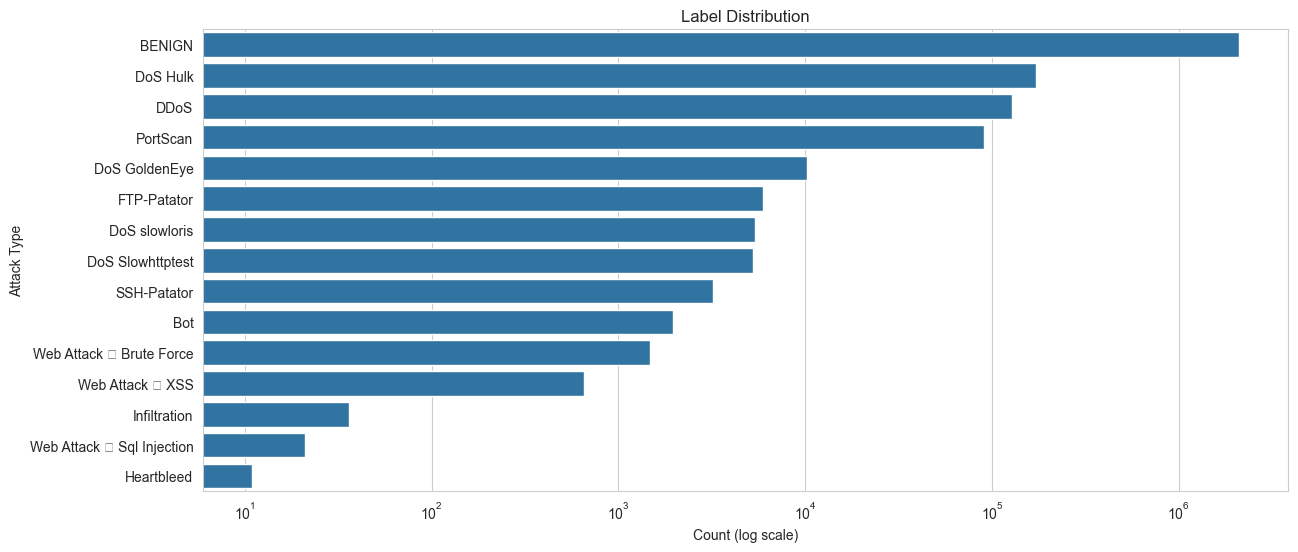

In [16]:
# ΚΕΛΙ 8
print(df['Label'].value_counts())

print("\nPercentages:")
print(df['Label'].value_counts(normalize=True) * 100)

plt.figure(figsize=(14,6))

sns.countplot(
    y=df['Label'],
    order=df['Label'].value_counts().index
)

plt.xscale('log')

plt.title("Label Distribution")
plt.xlabel("Count (log scale)")
plt.ylabel("Attack Type")

plt.show()

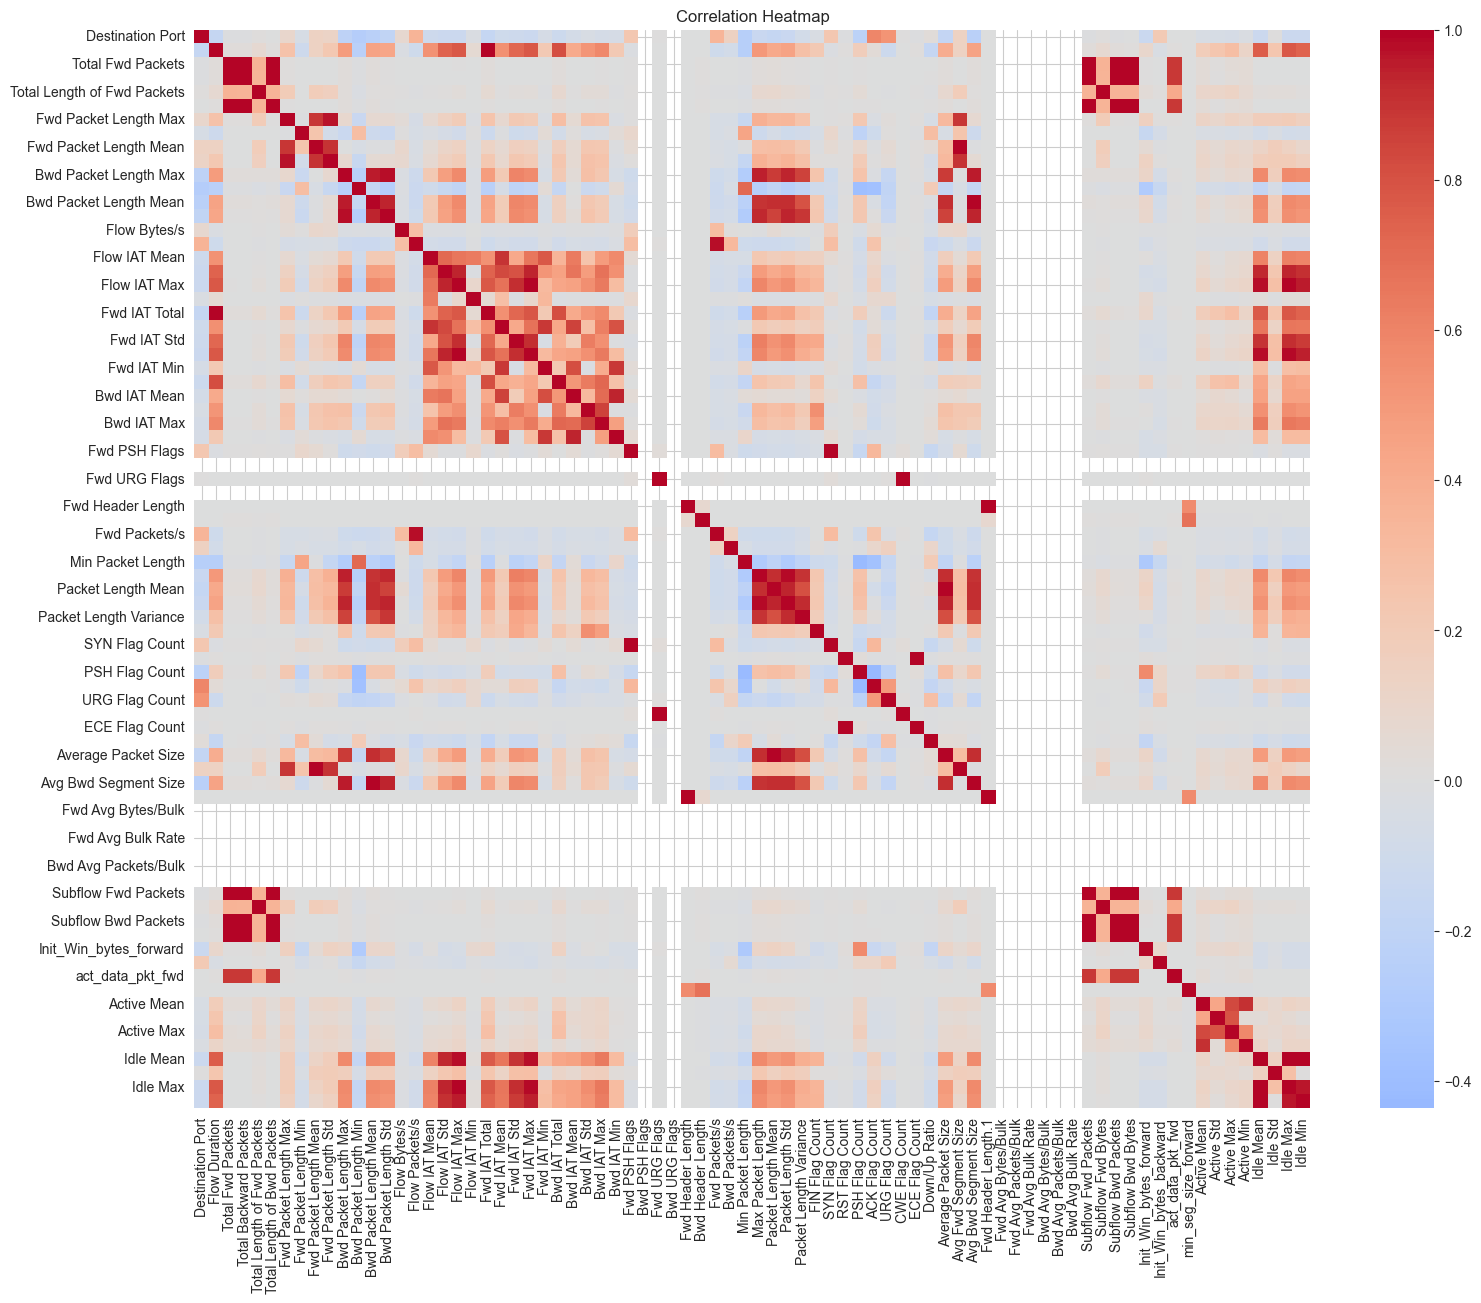

In [17]:
# ΚΕΛΙ 9: Επιλογή Χαρακτηριστικών (Feature Selection)

numeric_df = df.select_dtypes(include=np.number)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [18]:
# ΚΕΛΙ 10
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]

print("Highly Correlated Features:")
print(high_corr_features)

Highly Correlated Features:
['Total Backward Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd IAT Total', 'Fwd IAT Max', 'Fwd Packets/s', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Idle Mean', 'Idle Max', 'Idle Min']


In [ ]:
#ΚΕΛΙ 11
numeric_df = df.select_dtypes(include=np.number)

# Remove NaN rows
numeric_df.dropna(inplace=True)

In [22]:
#ΚΕΛΙ 12
selector = VarianceThreshold(threshold=0.01)

selector.fit(numeric_df)

low_variance_features = numeric_df.columns[
    ~selector.get_support()
]

print("Low Variance Features:")
print(list(low_variance_features))

Low Variance Features:
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'RST Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [ ]:
# ΚΕΛΙ 13
features_to_drop = list(high_corr_features) + list(low_variance_features)

features_to_drop = list(set(features_to_drop))

print("Features to remove:")
print(features_to_drop)

df_reduced = df.drop(columns=features_to_drop)

print("\nOriginal Shape:", df.shape)
print("Reduced Shape:", df_reduced.shape)

Features to remove:
['Avg Fwd Segment Size', 'Total Backward Packets', 'Bwd Avg Bulk Rate', 'Subflow Bwd Bytes', 'ECE Flag Count', 'Bwd URG Flags', 'Total Length of Bwd Packets', 'Bwd PSH Flags', 'SYN Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Idle Max', 'Subflow Fwd Bytes', 'Idle Mean', 'Bwd Avg Packets/Bulk', 'Fwd IAT Total', 'Avg Bwd Segment Size', 'Fwd Packet Length Std', 'CWE Flag Count', 'Bwd Packet Length Std', 'Subflow Bwd Packets', 'Fwd IAT Max', 'Average Packet Size', 'Subflow Fwd Packets', 'Fwd URG Flags', 'Bwd Packet Length Mean', 'Packet Length Std', 'Bwd Avg Bytes/Bulk', 'Fwd Avg Bulk Rate', 'Fwd Packets/s', 'RST Flag Count', 'Idle Min', 'Fwd Header Length.1']

Original Shape: (2522009, 79)
Reduced Shape: (2522009, 46)


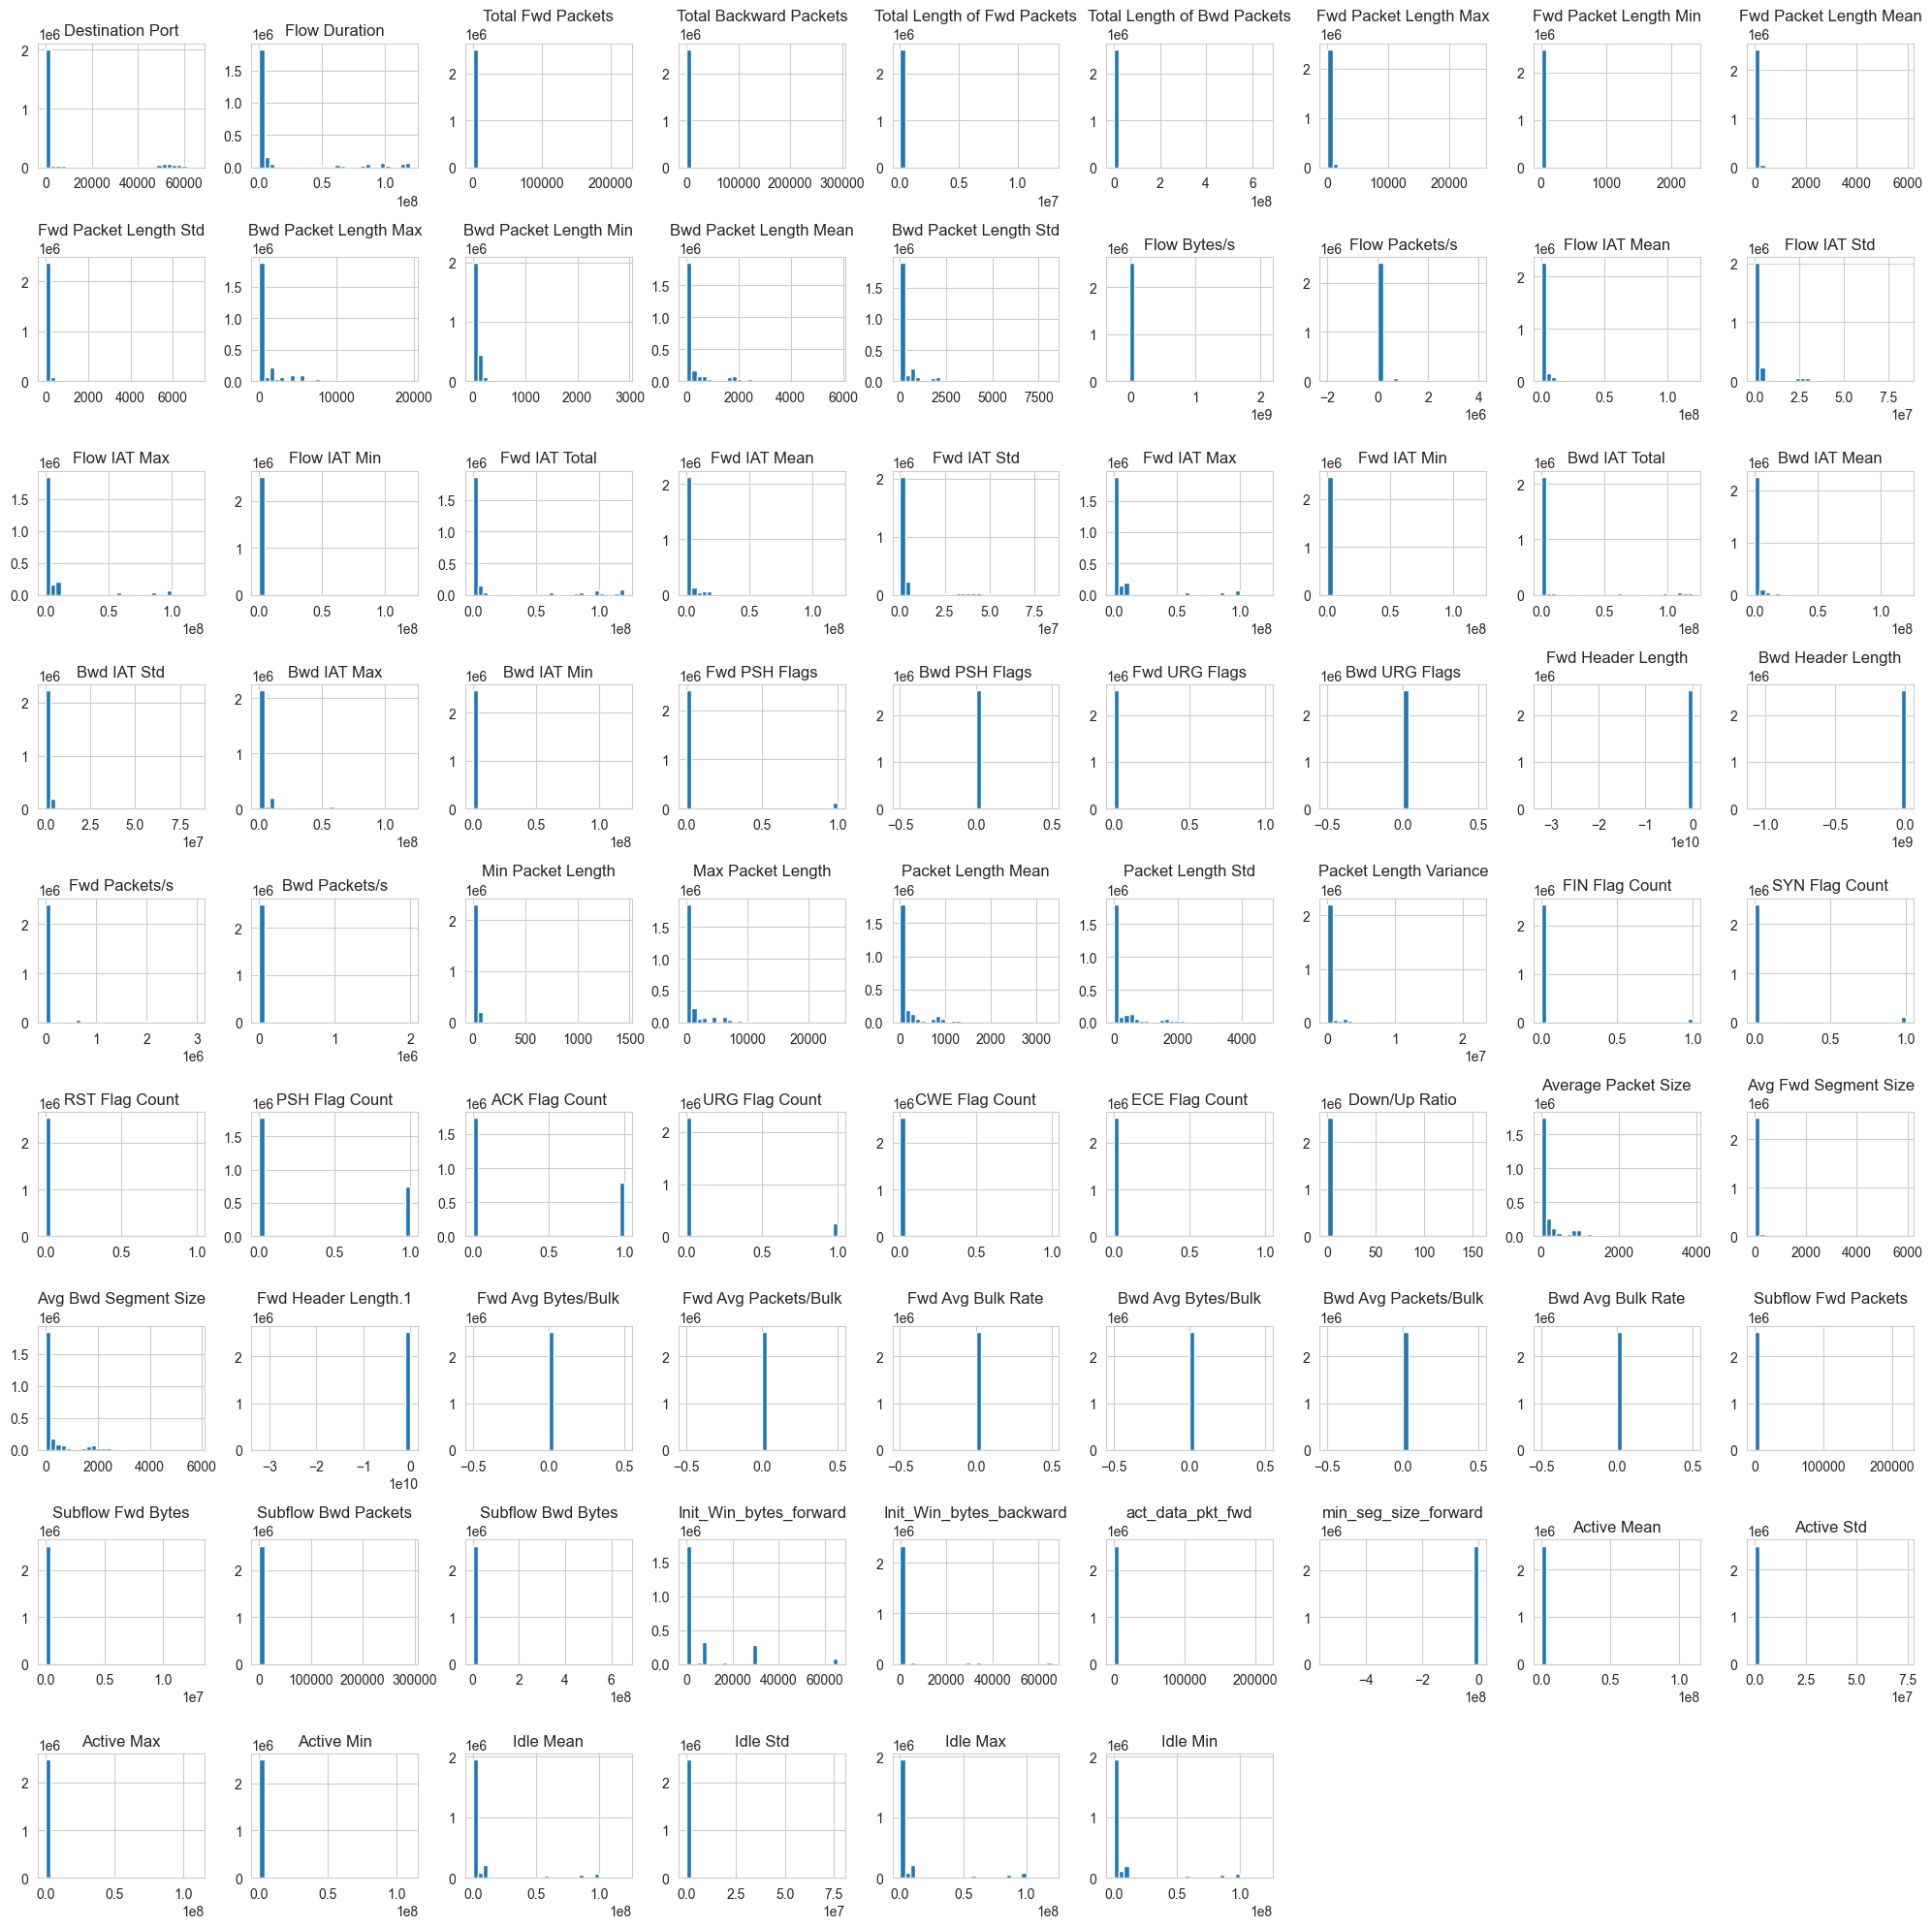

In [ ]:
# ΚΕΛΙ 14
numeric_df.hist(
    figsize=(20,20),
    bins=30
)

plt.tight_layout()
plt.show()

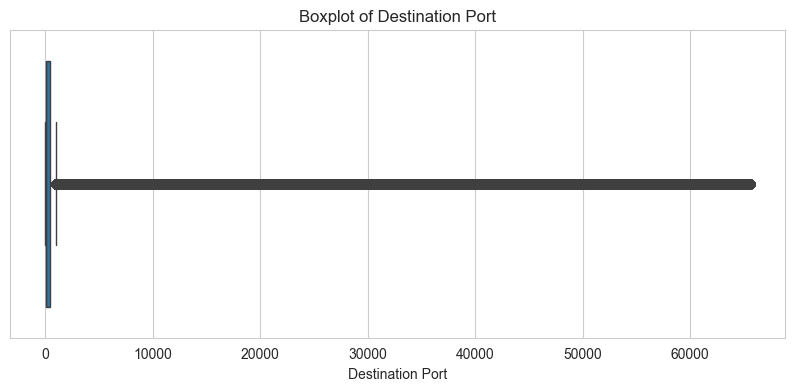

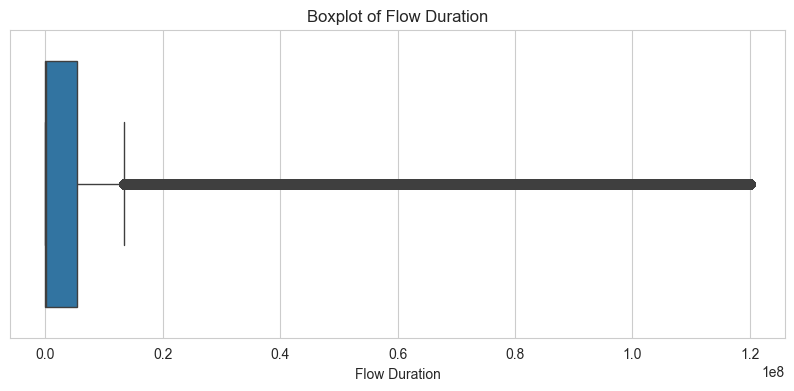

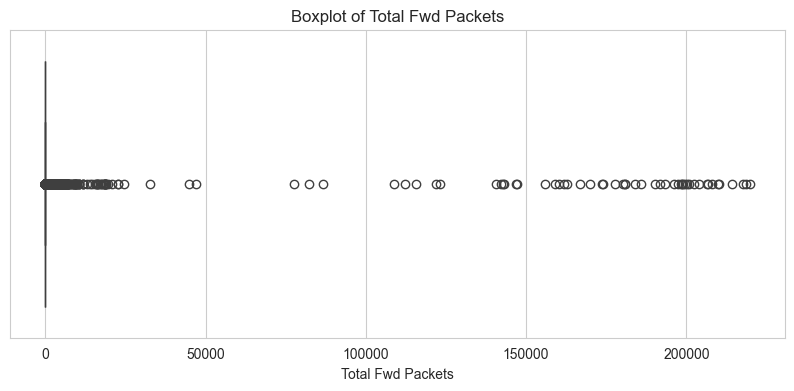

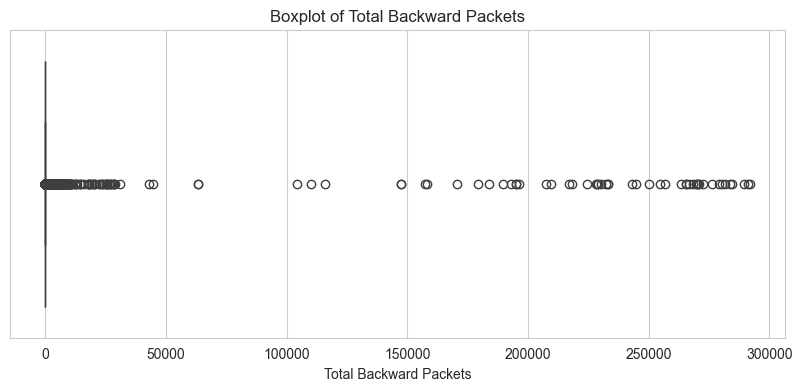

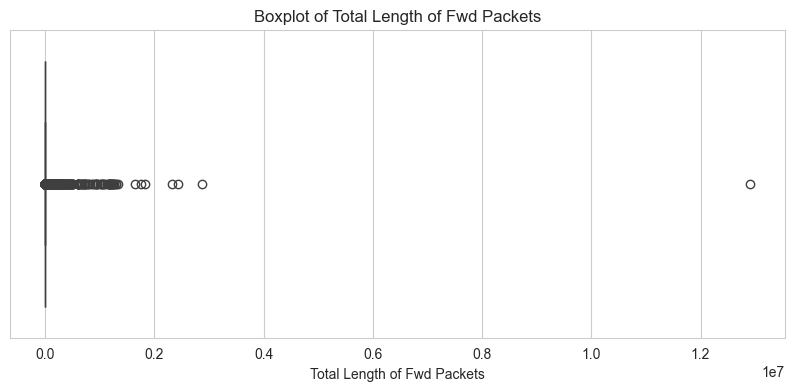

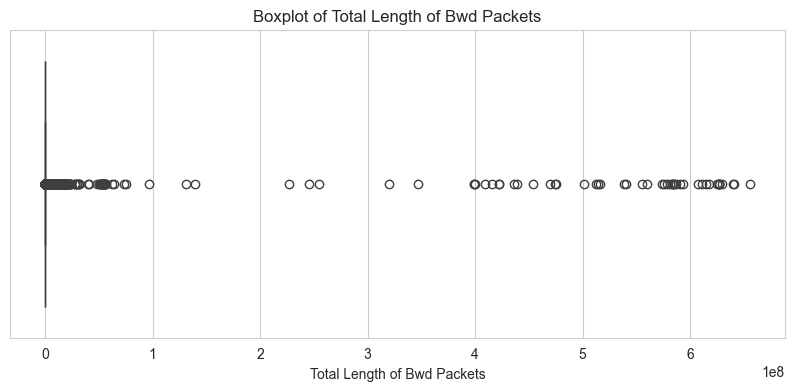

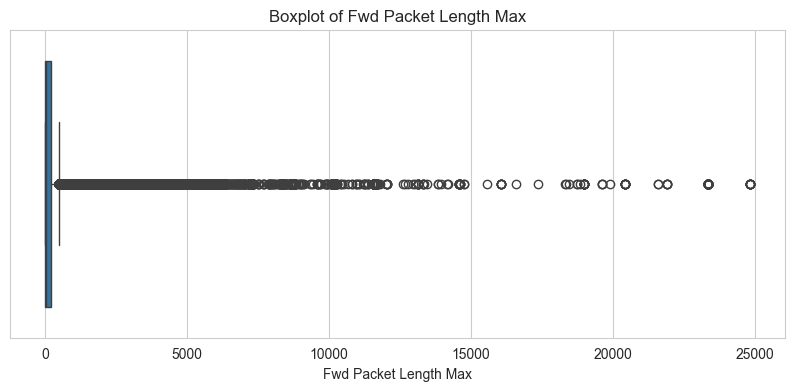

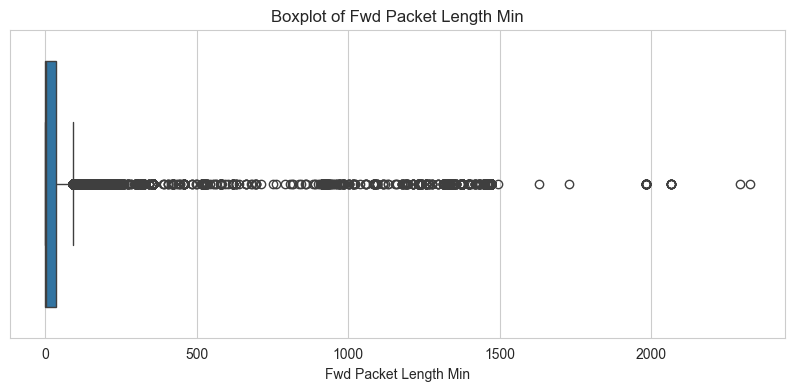

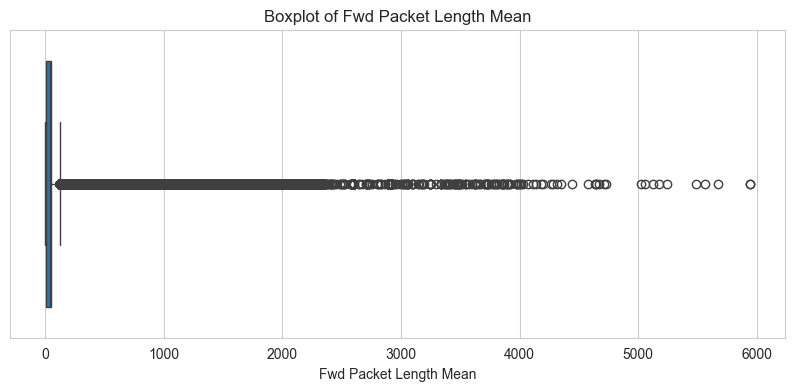

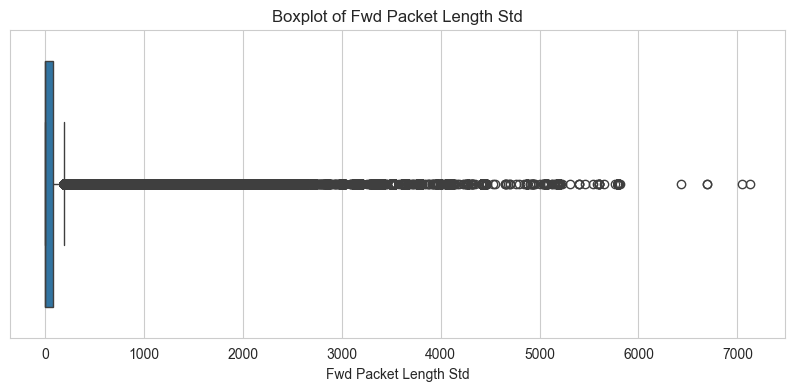

In [ ]:
# ΚΕΛΙ 15
sample_columns = numeric_df.columns[:10]

for col in sample_columns:

    plt.figure(figsize=(10,4))

    sns.boxplot(x=numeric_df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

C:\Users\spiro\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


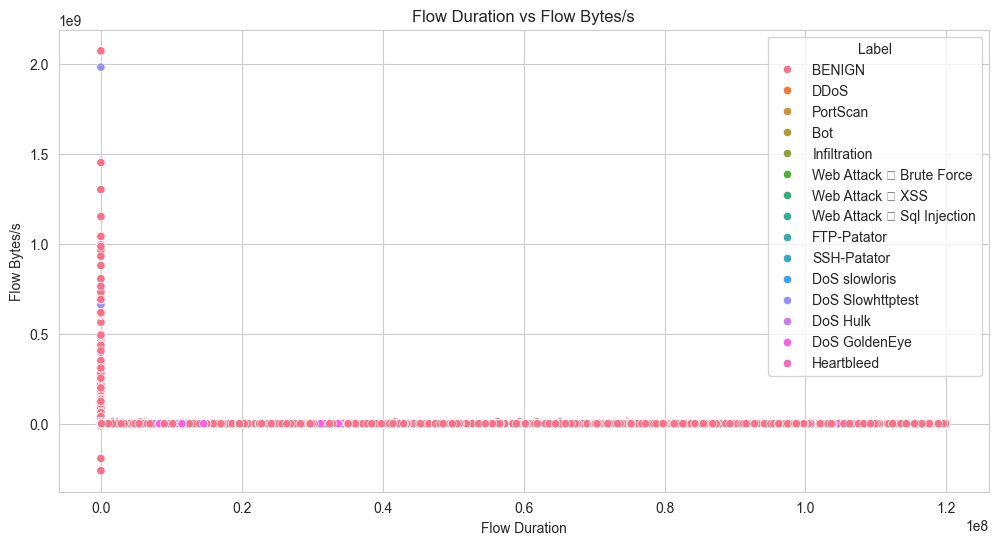

In [ ]:
# ΚΕΛΙ 16
sns.scatterplot(
    data=df,
    x='Flow Duration',
    y='Flow Bytes/s',
    hue='Label'
)

plt.title("Flow Duration vs Flow Bytes/s")

plt.show()